# Naïve state preparation

$$
\newcommand{\ket}[1]{|#1\rangle}
\newcommand{\bra}[1]{\langle#1|}
\newcommand{\norm}[1]{\left\lVert#1\right\rVert}
$$

An important primitive in quantum algorithms is arbitrary state preparation: given a list of amplitudes $\vec{a}$, come up with a circuit that takes the all-zero state to a superposition state weighted by $\vec{a}$. 

In some sense, arbitrary quantum state preparation is the whole point of any algorithm. This is **necessarily** a difficult task to perform (i.e. there does not exist an efficient circuit to do this). However, in many applications, such as qubitization, we want to prepare a state over a **logarithmically-sized** register, so we can tolerate its cost. 

Even still, the $\text{PREPARE}$ subroutine is where a sizable chunk of the $\text{T}$ count comes from for some algorithms, like qubitization. Cheaper state preparation techniques would go a long way in reducing the $\text{T}$ count for algorithms we care about. However, in this notebook, we cover one of the most naïve implementations, which serves as a useful canonical state preparation routine, and is also particularly sim-efficient.

## Grover-Rudolph style state prep

A [method for loading arbitrary quantum states](https://arxiv.org/abs/quant-ph/0208112) has existed for a while. This method, and [its more modern, ancilla-free variants](https://arxiv.org/pdf/quant-ph/0407010.pdf) are generally referred to as "Grover-Rudolph style" state preparation. 

The idea is the following: say you have an $n$-qubit all-zero state, and you want to prepare an orthonormal $n$-qubit state of the following form:

$$ \ket{\psi} = \frac{1}{\norm{\vec{a}}_2}\sum_{i = 0}^{2^n - 1}a_i\ket{i}$$

What you can do is perform a single-qubit rotation $e^{-iY\cos^{-1}p_0}$ (where $p_0$ is obtained by some function of $\vec{a}$) on the most significant bit of your all-zero state. Then, conditioned on that qubit, you perform another series of rotations (also by angles which are obtained via functions of $\vec{a}$) on the second most significant bit. You then continue to recursively apply $m$-controlled rotations conditioned on the previous $m$ bits. This looks something like:

![](./images/grover-rudolf-state-prep.png)

Naïvely this decomposes into $2^n - 1$ rotations, each of which then has to be decomposed into some number of $\text{T}$ gates.

### Uniformly-controlled rotations, or "multiplexed" rotations

The above circuit makes use of a cascading series of uniformly-controlled rotations. These are gates which work as follows: give me an index `x`, and I apply the `x`th rotation from some list of angles. Mathematically, this is the operation:

$$U = \sum_{x = 0}^{2^n - 1} \ket{x}\bra{x} \otimes e^{2\pi i \theta_x Y}$$

The most naïve implementation of this operation looks as follows:

![](./images/naive-multiplexor.png)

However, a more gate-efficient implementation is the following:

![](./images/better-multiplexor.png)

## Workbench implementation

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from psiqworkbench import Qubits, QPU
from workbench_algorithms import ArbitraryStatePrep, PrepareNaive
from psiqworkbench.utils.misc_utils import pad_to_pow2_length
from workbench_algorithms.utils import get_angles
import numpy as np

For the existing `Workbench` implementations, we have a few ingredients:
- A helper function called [`get_angles`](https://docs.construct.psiquantum.com/workbenchalgo/autoapi/workbench_algorithms/utils/state_prep_utils.html#workbench_algorithms.utils.state_prep_utils.get_angles).
- Two different `Qubricks` that implement "multiply-controlled" rotations.
- Two different `Qubricks` that execute arbitrary state preparation.

The two state preparation `Qubricks` variations are very similar, but pre-process the input list of values differently. One of these is [`ArbitraryStatePrep`](https://docs.construct.psiquantum.com/workbenchalgo/autoapi/workbench_algorithms/subroutines/naive_state_prep.html#workbench_algorithms.subroutines.naive_state_prep.ArbitraryStatePrep), which (as the name implies) is _true_ arbitrary state preparation; give me a list of amplitudes which can be _complex_, and I will prepare this list (normalized) as amplitudes in a quantum state. We also have [`PrepareNaive`](https://docs.construct.psiquantum.com/workbenchalgo/autoapi/workbench_algorithms/subroutines/naive_state_prep.html#workbench_algorithms.subroutines.naive_state_prep.PrepareNaive) which only works for _positive, real-valued_ coefficients, and instead loads the _square roots_ of the supplied list of values.

### [get_angles](https://docs.construct.psiquantum.com/workbenchalgo/autoapi/workbench_algorithms/utils/state_prep_utils.html#workbench_algorithms.utils.state_prep_utils.get_angles)

This helper function will generally never be used directly by the user, but is instead called within the state preparation methods. For completeness, we show its use here. The function works by taking in a list of amplitudes, and returns two lists of lists of angles. One of these lists is all Z rotations used for equalizing the phases (in case your amps are complex). The other list is all Y rotations used for changing the amplitude of the input all-zero state.

In this notebook, let's assume we are only working with positive, real amplitudes. As an example, suppose our list was:
```python
[18.862248108547448,
 8.078899059798434,
 7.634344662044846,
 11.968056901545925,
 11.290790200796636,
 3.0110594393238017,
 12.772811506335309,
 12.294665351785214,
 8.704091953744928,
 19.41560691909141]
```
We would then pass this to `get_angles`, which would then spit out Y rotations according to Eq. 8 [here](https://arxiv.org/pdf/quant-ph/0407010.pdf). Since the list is all positive, real valued, we can ignore the Z rotations list and only focus on the Y rotations:

In [3]:
amps = [18.862248108547448,
        8.078899059798434,
        7.634344662044846,
        11.968056901545925,
        11.290790200796636,
        3.0110594393238017,
        12.772811506335309,
        12.294665351785214,
        8.704091953744928,
        19.41560691909141]

_, y_angles = get_angles(amps)
y_angles

[[np.float64(46.371918842625455),
  np.float64(114.93292988493032),
  np.float64(29.864559354044406),
  np.float64(87.81450402462785),
  np.float64(131.706242517568),
  0,
  0,
  0],
 [np.float64(69.35190173303428),
  np.float64(113.22013503801546),
  np.float64(0.0),
  0],
 [np.float64(80.79466769026884), np.float64(0.0)],
 [np.float64(66.00186601225333)]]

We now have a list of lists; each of these lists contains a list of angles for the `m`th wire in the state prep qubit register. So the lowest bit only has one element, the next bit has two, the next has 4, etc.

### [PrepareNaive](https://docs.construct.psiquantum.com/workbenchalgo/autoapi/workbench_algorithms/subroutines/naive_state_prep.html#workbench_algorithms.subroutines.naive_state_prep.PrepareNaive)

Now we can show how to use state preparation as Qubricks to prepare a state with these amplitudes. For `PrepareNaive`, we will be loading the square-root (normalized) of these coefficients. This can be done with very few lines of code:

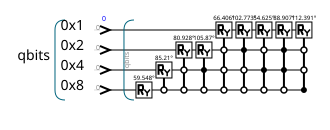

In [4]:
# determine requisite number of qubits
num_qubits = int(np.ceil(np.log2(len(amps))))

# set up QPU instance and Qubits object
qc = QPU()
qc.reset(num_qubits)
qc.write(0)
qbits = Qubits(num_qubits, 'qbits', qc)

# instantiate state prep Qubrick
prep = PrepareNaive(amps)

# call the compute method
prep.compute(qbits)

qc.draw()

Et voilà! We have implemented the state prep routine! We can inspect the resulting state and compare to the expected output:

In [5]:
# pull state from the sim
psi = qc.pull_state()

# process amps to normalize them and take square root to compare to the sim state
norm = sum(amp for amp in amps)
processed_amps = pad_to_pow2_length([np.sqrt(amp / norm) for amp in amps])
assert np.allclose(psi, processed_amps)

## Different choices for multiplexor

By default, these state prep routines use the most naïve (and thus sim-efficient) uniformly-controlled rotations (or multiplexors). However, you could opt to use either multiplexor depicted earlier in these routines.

In [6]:
from workbench_algorithms import NaiveMultiplexedRotations, EfficientMultiplexedRotations

Let's look at the same code sample as before, but plug in a particular multiplexed rotations `Qubrick`:

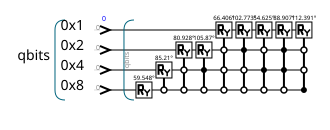

In [7]:
num_qubits = int(np.ceil(np.log2(len(amps))))

# set up QPU instance and Qubits object
qc = QPU()
qc.reset(num_qubits)
qc.write(0)
qbits = Qubits(num_qubits, 'qbits', qc)

# instantiate state prep and mplxr Qubrick
mplxr = NaiveMultiplexedRotations()
prep = PrepareNaive(amps, mplxr)

# call the compute method
prep.compute(qbits)

qc.draw()

Here we explicitly passed in [`NaiveMultiplexedRotations()`](https://docs.construct.psiquantum.com/workbenchalgo/autoapi/workbench_algorithms/subroutines/naive_state_prep.html#workbench_algorithms.subroutines.naive_state_prep.NaiveMultiplexedRotations), whereas before we just defaulted to this. Using the _exact_ same code, but instantiating [`EffficientMultiplexedRotations()`](https://docs.construct.psiquantum.com/workbenchalgo/autoapi/workbench_algorithms/subroutines/naive_state_prep.html#workbench_algorithms.subroutines.naive_state_prep.EfficientMultiplexedRotations) instead, we can reproduce the exact same state with fewer gates:

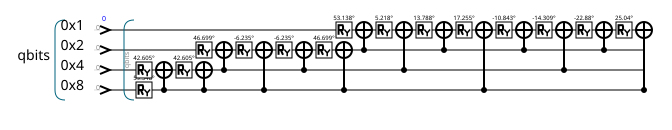

In [8]:
num_qubits = int(np.ceil(np.log2(len(amps))))

# set up QPU instance and Qubits object
qc = QPU()
qc.reset(num_qubits)
qc.write(0)
qbits = Qubits(num_qubits, 'qbits', qc)

# instantiate state prep and mplxr Qubrick
mplxr = EfficientMultiplexedRotations()
prep = PrepareNaive(amps, mplxr)

# call the compute method
prep.compute(qbits)

qc.draw()

## Summary

- We have two naïve state prep routines, `ArbitraryStatePrep` and `PrepareNaive`
- We looked at `PrepareNaive`, which only works for real, positive-values inputs
- In practice, we will only use this version rather than `ArbitraryStatePrep`
- These routines make use of "multiplexed" rotations, and we have both an efficient version (`EfficientMultiplexedRotations`) and an inefficient version (`NaiveMultiplexedRotations`)

That's all there is to it; have fun preparing states!